
## 1. Exploración de los datos
Realiza un análisis exploratorio del conjunto de datos que incluya:
- Dimensiones del dataset. 
- Tipos de variables. 
- Valores nulos. 
- Registros duplicados. 
- Estadísticos descriptivos. 
- Visualizaciones que permitan comprender la información. 

## 2. Preparación de los datos
Realiza el preprocesamiento necesario para aplicar técnicas de clustering.
Debes justificar cada decisión tomada.
Por ejemplo:
- Eliminación de variables irrelevantes. 
- Transformación del dataset para obtener variables por usuario. 
- Ingeniería de características (si aplica). 
- Escalamiento de variables. 
Importante: El dataset original se encuentra en formato de interacciones usuario–videojuego. Será necesario transformarlo para construir variables representativas de cada usuario antes de realizar el clustering.

## 3. Modelado
Implementa un algoritmo de clustering, por ejemplo:
- K-Means 
- DBSCAN 
- Clustering Jerárquico 
Justifica la elección del algoritmo utilizados.

## 4. Interpretación de los clusters
Describe cada uno de los grupos encontrados.
Puedes responder preguntas como:
- Qué caracteriza a los usuarios de este grupo? 
- Son jugadores ocasionales o frecuentes? 
- Presentan comportamientos similares de compra? 
- Qué diferencias existen entre los clusters? 
Asigna un nombre representativo a cada segmento.
Ejemplo:
- Jugadores Casual 
- Coleccionistas 
- Usuarios Muy Activos 
- Compradores Frecuentes
## 5. Recomendaciones de negocio
Con base en los segmentos encontrados, responde:
- Qué estrategia de marketing implementarías para cada grupo? 
- Qué tipo de promociones recibiría cada segmento? 
- Qué usuarios priorizarías para campañas de fidelización? 
- Qué información adicional sería útil para mejorar la segmentación?

In [1]:
from sklearn.datasets import make_moons, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

## 1. Exploración de los datos

In [2]:
# Carga del dataset
df = pd.read_csv('dataset.csv', header=None, names=["user_id", "game_title", "behavior_name", "value", "?"]) # No tiene header y le pre-agrego uno para que no pierda un registro
df.head()

,user_id,game_title,behavior_name,value,?
0,151603712,The Elder Scrolls V Skyrim,purchase,1.0,0
1,151603712,The Elder Scrolls V Skyrim,play,273.0,0
2,151603712,Fallout 4,purchase,1.0,0
3,151603712,Fallout 4,play,87.0,0
4,151603712,Spore,purchase,1.0,0


In [3]:
# Dimensiones
print("Dimensiones del dataset:", df.shape)

Dimensiones del dataset: (200000, 5)


In [4]:
# Tipos de datos
print("Tipos de datos del dataset:\n", df.dtypes)

Tipos de datos del dataset:
 user_id            int64
game_title           str
behavior_name        str
value            float64
?                  int64
dtype: object


In [5]:
# Nulos
print("Cantidad de valores nulos por columna:\n", df.isnull().sum())

Cantidad de valores nulos por columna:
 user_id          0
game_title       0
behavior_name    0
value            0
?                0
dtype: int64


In [6]:
# Dupes

print("Cantidad de registros duplicados:", df.duplicated().sum())

Cantidad de registros duplicados: 707


In [7]:
df.head(10)

,user_id,game_title,behavior_name,value,?
0,151603712,The Elder Scrolls V Skyrim,purchase,1.0,0
1,151603712,The Elder Scrolls V Skyrim,play,273.0,0
2,151603712,Fallout 4,purchase,1.0,0
3,151603712,Fallout 4,play,87.0,0
4,151603712,Spore,purchase,1.0,0
5,151603712,Spore,play,14.9,0
6,151603712,Fallout New Vegas,purchase,1.0,0
7,151603712,Fallout New Vegas,play,12.1,0
8,151603712,Left 4 Dead 2,purchase,1.0,0
9,151603712,Left 4 Dead 2,play,8.9,0


In [8]:
# valores únicos por columna
print("Valores únicos por columna:\n", df.nunique())

Valores únicos por columna:
 user_id          12393
game_title        5155
behavior_name        2
value             1593
?                    1
dtype: int64


In [9]:
# Estadísticas descriptivas
print("Estadísticas descriptivas del dataset:\n", df.describe())

Estadísticas descriptivas del dataset:
             user_id          value         ?
count  2.000000e+05  200000.000000  200000.0
mean   1.036559e+08      17.874384       0.0
std    7.208074e+07     138.056952       0.0
min    5.250000e+03       0.100000       0.0
25%    4.738420e+07       1.000000       0.0
50%    8.691201e+07       1.000000       0.0
75%    1.542309e+08       1.300000       0.0
max    3.099031e+08   11754.000000       0.0


/tmp/ipykernel_231173/4188808371.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="behavior_name", palette="Set2")


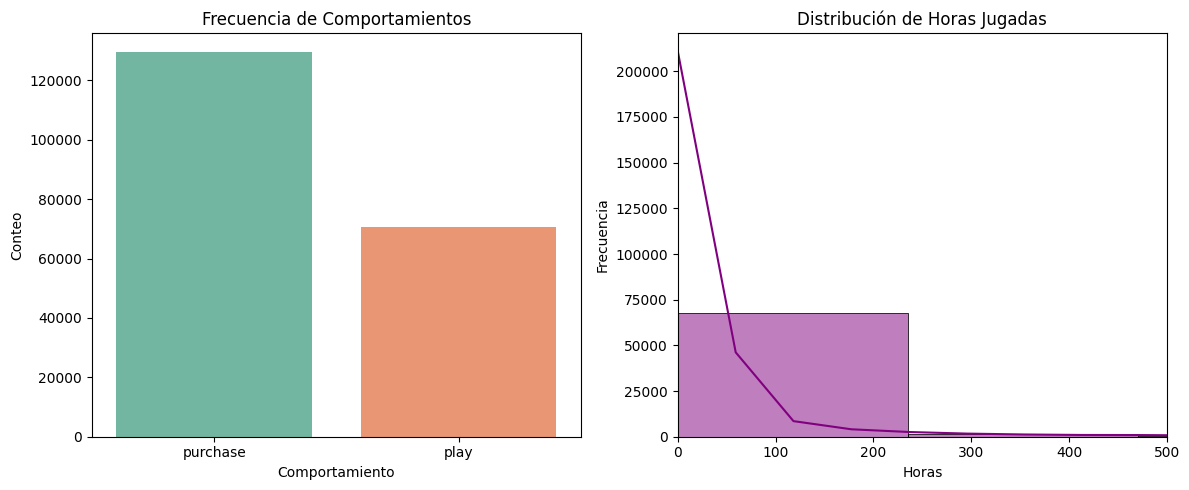

In [10]:
# Visualizaciones exploratiorias

plt.figure(figsize=(12, 5))

# Comportamiento (purchase vs. play)
plt.subplot(1, 2, 1)
sns.countplot(data=df, x="behavior_name", palette="Set2")
plt.title("Frecuencia de Comportamientos")
plt.xlabel("Comportamiento")
plt.ylabel("Conteo")

# Distribución de horas jugadas (excluyendo compras donde value=1)
plt.subplot(1, 2, 2)
play_df = df[df["behavior_name"] == "play"]
sns.histplot(play_df["value"], bins=50, kde=True, color="purple")
plt.title("Distribución de Horas Jugadas")
plt.xlabel("Horas")
plt.ylabel("Frecuencia")
plt.xlim(0, 500)

plt.tight_layout()
plt.show()

## 2. Preparación de los datos

In [11]:
# Puedo hacer un análisis de comportamiento de los usuarios, por ejemplo, cuántos usuarios han comprado
# y cuántos han jugado, así como la cantidad total de horas jugadas por usuario.
purchases = df[df["behavior_name"] == "purchase"].groupby("user_id").size().rename("total_purchased")
plays_sum = df[df["behavior_name"] == "play"].groupby("user_id")["value"].sum().rename("total_hours")
plays_count = df[df["behavior_name"] == "play"].groupby("user_id").size().rename("games_played")

In [12]:
user_df = pd.concat([purchases, plays_sum, plays_count], axis=1).fillna(0) # Testeando si puedo agrupar a nivel de usuario

# Horas promedio por juego
user_df["avg_hours_per_game"] = user_df["total_hours"] / user_df["games_played"].replace(0, 1)
# Con qué frecuencia juegan lo que compraron
user_df["play_to_purchase_ratio"] = user_df["games_played"] / user_df["total_purchased"].replace(0, 1)
print("Análisis de comportamiento por usuario:\n", user_df.head())

Análisis de comportamiento por usuario:
          total_purchased  total_hours  games_played  avg_hours_per_game  \
user_id                                                                   
5250                  21        225.5           6.0           37.583333   
76767                 36       1227.0          20.0           61.350000   
86540                 82        255.0          15.0           17.000000   
103360                10          0.0           0.0            0.000000   
144736                 8          0.1           1.0            0.100000   

         play_to_purchase_ratio  
user_id                          
5250                   0.285714  
76767                  0.555556  
86540                  0.182927  
103360                 0.000000  
144736                 0.125000  


In [13]:
user_df.head()

,total_purchased,total_hours,games_played,avg_hours_per_game,play_to_purchase_ratio
user_id,,,,,
5250,21,225.5,6.0,37.583333,0.285714
76767,36,1227.0,20.0,61.350000,0.555556
86540,82,255.0,15.0,17.000000,0.182927
103360,10,0.0,0.0,0.000000,0.000000
144736,8,0.1,1.0,0.100000,0.125000


In [14]:
# Estandarización de los datos para clustering
X, y = make_blobs(n_samples=300, n_features=2, centers=3, cluster_std=2.5, random_state=42)
scaler_blob = StandardScaler()
X_scaled = scaler_blob.fit_transform(X)

scaler = StandardScaler()
user_scaled = scaler.fit_transform(user_df)

Text(0, 0.5, 'Componente 2')

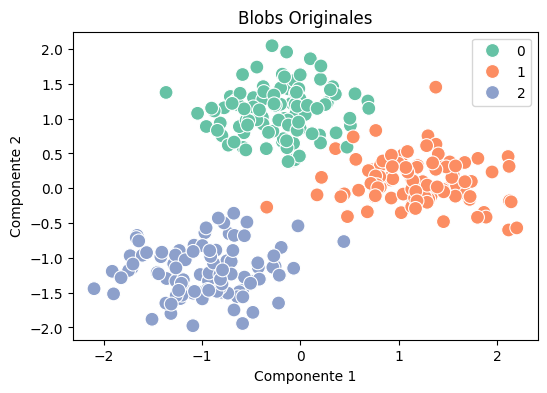

In [15]:
# blobs originales

plt.figure(figsize=(6, 4))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=y, palette="Set2", s=100)
plt.title("Blobs Originales")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")

## 3. Modelado

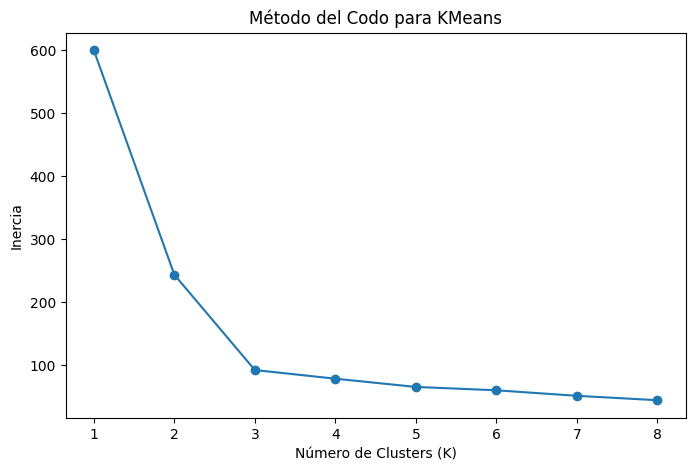

In [16]:
# Algoritmo seleccionado: KMeans, escala bien con grandes volúmenes de usuarios, DBSCAN es bueno con outliers, pero este dataset
# aparentemente no tiene muchos outliers, así que KMeans es una buena opción, además de poder definir K.

# Elbow method para determinar el número óptimo de clusters
inertias = []
K_range = range(1, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o')
plt.title("Método del Codo para KMeans")
plt.xlabel("Número de Clusters (K)")
plt.ylabel("Inercia")
plt.show()


### Entre 3 - 4 clusteres según el elbow method, 3 está mejor

Text(0, 0.5, 'Componente 2')

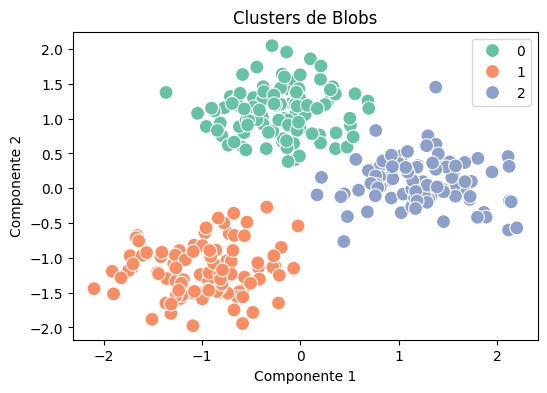

In [17]:
# Kmeans con blobs
optimal_k = 3
kmeans_blob = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
blob_labels = kmeans_blob.fit_predict(X_scaled)

plt.figure(figsize=(6, 4))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=blob_labels, palette="Set2", s=100)
plt.title("Clusters de Blobs")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")

> Sin blobs es horrible jajajaja

In [18]:
# Para interpretación

optimal_k_user = 3
kmeans_user = KMeans(n_clusters=optimal_k_user, random_state=42, n_init=10)
user_labels = kmeans_user.fit_predict(user_scaled)

## 4. Interpretación de los clusters

In [19]:
user_df["cluster"] = user_labels
cluster_summary = user_df.groupby("cluster").agg(
    usuarios=("total_hours", "count"),
    total_hours=("total_hours", "mean"),
    games_played=("games_played", "mean"),
    total_purchased=("total_purchased", "mean"),
    avg_hours_per_game=("avg_hours_per_game", "mean"),
    play_to_purchase_ratio=("play_to_purchase_ratio", "mean")
).reset_index()

print("Resumen de Clusters:\n", cluster_summary)

Resumen de Clusters:
    cluster  usuarios  total_hours  games_played  total_purchased  \
0        0      3974   213.702718      3.630096         9.959487   
1        1      7981   165.155557      3.177045         3.776845   
2        2       438  2917.818950     70.107306       136.504566   

   avg_hours_per_game  play_to_purchase_ratio  
0           71.934052                0.284835  
1           64.690072                0.952293  
2          271.478706                0.601667  


> Los valores de estas interpretaciones son aproximados

**Grupo 0: Jugadores Casuales**
> Jugadores que compran juegos esporádicamente, tienen juegos *favoritos*, que son los que más repiten, y juegos *empolvados* que compran pero nunca juegan.
 - En cantidad total de usuarios, este se posiciona en medio, con *3974* usuarios únicos.
 - En este grupo los usuarios tienen un Promedio total de horas jugadas de *214* independientemente de la cantidad de juegos comprados.
 - En este grupo los usuarios tienen un Promedio total de juegos comprados de casi *10* juegos comprados, de los cuales han jugado *3½* aproximadamente, en un promedio de *71* horas por videojuego, lo que dice que el *28%* de los juegos que compran, los juegan, siendo este grupo, el grupo que menos juega los juegos que compra.

**Grupo 1: Jugador Temporal**
> Grupo mayoría, compran solo los juegos que van a jugar, probablemente influenciados por sus amigos (se obtendría una mejor precisión en este sentido si tuviéramos una categoría de "singleplayer o multiplayer").
 - En cantidad total de usuarios, se posiciona de primero, con *7981* usuarios únicos.
 - En este grupo los usuarios tienen un Promedio total de horas jugadas de *165* independientemente de la cantidad de juegos comprados.
 - En este grupo los usuarios tienen un Promedio total de juegos comprados de casi *4* juegos comprados, de los cuales han jugado *3* aproximadamente, en un promedio de *65* horas por videojuego, lo que dice que el *95%* de los juegos que compran, los juegan, siendo este grupo, el grupo que más juega los juegos que compra.

**Grupo 2: Jugador Empedernido**
> Pese a ser el grupo más pequeño son el grupo que más tiempo y dinero le dedica al hobby, tienen cientos de horas por juego, probablemente sean del grupito que influencia a los *jugadores temporales* jajaja.
 - En cantidad total de usuarios, se posiciona de ultimo, con *438* usuarios únicos.
 - En este grupo los usuarios tienen un Promedio total de horas jugadas de *2918* independientemente de la cantidad de juegos comprados.
 - En este grupo los usuarios tienen un Promedio total de juegos comprados de casi *137* juegos comprados, de los cuales han jugado *70* aproximadamente, en un promedio de *271* horas por videojuego, lo que dice que el *60%* de los juegos que compran, los juegan.
 
 
---

## 5. Recomendaciones de negocio

**¿Qué estrategia de marketing implementarías para cada grupo?**
- Para el *Grupo 0: Jugadores Casuales* y el *Grupo 2: Jugador Empedernido*, promovería una dinámica de "descubre joyas ocultas en tu biblioteca", en la que los jugadores se animen a probar juegos que no han tocado, para así darles a esos juegos oportunidad de tener visiblildad en las bases de datos de la Tienda. Para el *Grupo 2: Jugador Empedernido*, promocionar juegos que no demanden mucho tiempo y a la vez sean populares, para mantener ese índice tan alto de jugabilidad para los juegos que compran.
  
**¿Qué tipo de promociones recibiría cada segmento?**
- Para el *Grupo 2: Jugador Empedernido*, se podrían agregar "bundles" de juegos, que, al ser el segmento con más juegos, es probable que algunos de estos juegos estén incluídos en estos "bundles" haciendo que el precio del mismo disminuya y sea más tentativo de comprar. Para el *Grupo 0: Jugadores Casuales* y el *Grupo 1: Jugador Temporal*, festivales de indies o multijugadores coop en los que hayan descuentos y recompensas en estas categorías de juegos.
  
**¿Qué usuarios priorizarías para campañas de fidelización?**
- Priorizaría los del *Grupo 2: Jugador Empedernido*, pese a que son menos jugadores, el índice de compra es alto, por lo que asegurarse de que este índice se mantenga debería ser una prioridad.
  
**¿Qué información adicional sería útil para mejorar la segmentación?**
- Categorías de juegos, cantidad de jugadores (duos, tríos, multijugador masivo, coop), modalidades, rangos de precios de los juegos, índice de popularidad.
